PERSONALIZED STUDY ASSISTANT AGENT

IMPLEMENTATION TO LEARN ABOUT CHECKPOINTING, PERSISTENCE AND LONG SHORT TERM MEMORY IN AGENTIC AI USING LANGGRAPH

In [8]:
#imports
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages

#State Schema
#Defining short term state (Dies within a single thread id)
class State(TypedDict):
    #Using reducers to append the messages
    messages: Annotated[list, add_messages]

In [9]:
#getting the imports
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

#initializing the llm
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("GEMINI_API_KEY")

#initilazing the llm
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash", temperature = 0.5)

In [10]:
#using inMemoryStore for long term memory
from langgraph.store.memory import InMemoryStore

#It acts as the long-term database across threads
#we can use any production level database in place of this
long_term_store = InMemoryStore()

In [11]:
#Defining Nodes
def study_assistant(state: State, config: dict = None):
    if config is None:
        config = {}
    #extracting the configurable parameters passed during invocation
    #'configurable' contains metadata like the current thread_id and user_id
    configurable = config.get("configurable", {})
    user_id = configurable.get("user_id", "default_user")

    #Accessing the Long term memory
    #We fetch any saved preferences under a specific namespace tuple : {profile, user_id}
    stored_memory = long_term_store.get(("profile", user_id), "user_preference")

    #Creating context based on long term memory
    profile_context = ""
    if stored_memory and "info" in stored_memory.value:
        profile_context  = f"You know this about the user: {stored_memory.value['info']}"
    
    #Inject long term context into the System Prompt
    system_prompt = (
        f"You are helpful study assistant. {profile_context}"
        "Keep your answers structured, clear and conceptual"
    )    

    #Assemble the full message list: System Message + current thread history
    messages = [SystemMessage(content = system_prompt)] + state["messages"]

    #Invoking the Model
    response = model.invoke(messages)

    #Returing the updated Short Term Memory
    return {"messages": [response]}


In [12]:
#compiling the graph with checkpointers
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

#initializing the stategraph with short term state structure
workflow = StateGraph(State)

#Adding Nodes
workflow.add_node("assistant", study_assistant)

#Defining the routing execution flow (Start->Assistant->End)
workflow.add_edge(START, "assistant")
workflow.add_edge("assistant", END)

#Initializing Short Term Memory using Checkpointer
#MemorySaver records the state history of every thread execution step in RAM
checkpointer = MemorySaver()

#Compile the graph by binding the checkpointer and the Long term store
app = workflow.compile(checkpointer = checkpointer, store = long_term_store)

/tmp/ipykernel_3817/2185187502.py:9: UserWarning: The 'config' parameter should be typed as 'RunnableConfig' or 'RunnableConfig | None', not '<class 'dict'>'. 
  workflow.add_node("assistant", study_assistant)


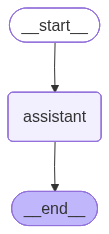

In [13]:
#Visualizing the Graph
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
# Configuration establishing Thread 1 for User "Shourya"
config_thread_1 = {"configurable": {"thread_id": "1", "user_id": "shourya_01"}}

# First interaction
events = app.stream(
    {"messages": [HumanMessage(content="Hi, I'm preparing for my post-grad thesis on RAG architectures.")]}, 
    config_thread_1
)
for event in events:
    event["assistant"]["messages"][-1].pretty_print()

# Second interaction on the SAME thread
events = app.stream(
    {"messages": [HumanMessage(content="What was the topic I just said I am preparing for?")]}, 
    config_thread_1
)
for event in events:
    event["assistant"]["messages"][-1].pretty_print()
# The agent successfully answers "RAG architectures" because of the short-term thread checkpointer.

================================== Ai Message ==================================

Understood! You're preparing for your post-grad thesis on **RAG architectures**.

That's a fantastic and highly relevant area of study. I've already provided a comprehensive overview of RAG, its components, benefits, and potential thesis focus areas.

To continue our discussion, what specific aspect of RAG would you like to explore further? For instance, we could dive into:

*   **Specific challenges** within RAG (e.g., retrieval quality, context management).
*   **Advanced RAG patterns** (e.g., iterative RAG, agentic RAG).
*   **Evaluation methodologies** for RAG systems.
*   **Specific tools or frameworks** (e.g., LangChain, LlamaIndex).
*   **Potential research questions** or areas for your thesis.

Just let me know where you'd like to focus!
================================== Ai Message ==================================

You just said you are preparing for your post-grad thesis on **RAG architectures

In [20]:
# Saving a persistent preference across all future sessions for this specific user
long_term_store.put(
    ("profile", "shourya_01"), 
    "user_preferences", 
    {"info": "The user is pursuing post-grad studies and focuses on RAG and conceptual guidance."}
)

In [21]:
# A completely clean short-term thread, but keeping the same user_id
config_thread_2 = {"configurable": {"thread_id": "2", "user_id": "shourya_01"}}

events = app.stream(
    {"messages": [HumanMessage(content="Hi! Do you know what academic topic I focus on?")]}, 
    config_thread_2
)
for event in events:
    event["assistant"]["messages"][-1].pretty_print()
# The short-term conversation history is empty, but it will pull from the long-term store 
# and confidently answer that you focus on RAG!

================================== Ai Message ==================================

Hello there!

No, I still don't know what academic topic you focus on. Think of me as a brand new assistant each time you ask – I don't have any memory of our previous interactions or any personal information about you.

To help you, you'll need to tell me what your academic topic is! Once you share it, I'll be happy to assist you with questions, explanations, or anything else you need.
